# Exploring the Relationship Between Trader Performance and Market Sentiment

## Table of Contents

1. Import Required Libraries
2. Load the Datasets
3. Data Inspection
4. Data Preprocessing
5. Dataset Integration
6. Exploratory Data Analysis
7. Statistical Validation
8. Hidden Pattern Discovery
9. Data Visualization
10. Key Findings and Business Insights

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, shapiro

sns.set_style("whitegrid")

In [44]:
history = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [45]:
print("Historical Data")
display(history.head())

print(history.info())

print("\nFear Greed Data")
display(sentiment.head())

print(sentiment.info())

Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18608 entries, 0 to 18607
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           18608 non-null  object 
 1   Coin              18608 non-null  object 
 2   Execution Price   18608 non-null  float64
 3   Size Tokens       18608 non-null  float64
 4   Size USD          18608 non-null  float64
 5   Side              18608 non-null  object 
 6   Timestamp IST     18608 non-null  object 
 7   Start Position    18608 non-null  float64
 8   Direction         18608 non-null  object 
 9   Closed PnL        18607 non-null  float64
 10  Transaction Hash  18607 non-null  object 
 11  Order ID          18607 non-null  float64
 12  Crossed           18607 non-null  object 
 13  Fee               18607 non-null  float64
 14  Trade ID          18607 non-null  float64
 15  Timestamp         18607 non-null  float64
dtypes: float64(9), object(7)
memory usage: 2

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [46]:
print(history.columns.tolist())
print(sentiment.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
['timestamp', 'value', 'classification', 'date']


In [47]:
# Remove rows with missing important values

history = history.dropna(subset=[
    "Timestamp IST",
    "Closed PnL",
    "Size USD",
    "Fee"
])

history.reset_index(drop=True, inplace=True)

In [48]:
# Convert trading timestamp to datetime

history["Timestamp IST"] = pd.to_datetime(
    history["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Keep only the date

history["date"] = history["Timestamp IST"].dt.date

# Convert sentiment date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [49]:
merged = pd.merge(
    history,
    sentiment,
    on="date",
    how="inner"
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (18601, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [50]:
print(merged.columns)

print()

print(merged[[
    "date",
    "classification",
    "value",
    "Closed PnL"
]].head())

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

         date classification  value  Closed PnL
0  2024-12-02  Extreme Greed     80         0.0
1  2024-12-02  Extreme Greed     80         0.0
2  2024-12-02  Extreme Greed     80         0.0
3  2024-12-02  Extreme Greed     80         0.0
4  2024-12-02  Extreme Greed     80         0.0


In [51]:
summary = merged.groupby("classification").agg(
    Trades=("Closed PnL", "count"),
    Avg_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Std_PnL=("Closed PnL", "std"),
    Avg_Size_USD=("Size USD", "mean"),
    Avg_Fee=("Fee", "mean")
)

summary = summary.round(2)

summary

,Trades,Avg_PnL,Median_PnL,Std_PnL,Avg_Size_USD,Avg_Fee
classification,,,,,,
Extreme Fear,747,338.92,0.00,4815.53,7681.77,1.13
Extreme Greed,1600,65.94,0.00,1556.94,8437.32,1.32
Fear,8414,194.77,0.00,2231.37,30507.74,4.88
Greed,4732,136.22,0.00,2524.39,28037.00,5.56
Neutral,3108,178.84,0.62,931.51,25822.78,4.80


In [52]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("classification")["Win"]
    .mean()
    .mul(100)
    .round(2)
)

win_rate

,Win
classification,
Extreme Fear,32.26
Extreme Greed,11.50
Fear,41.56
Greed,35.04
Neutral,54.28


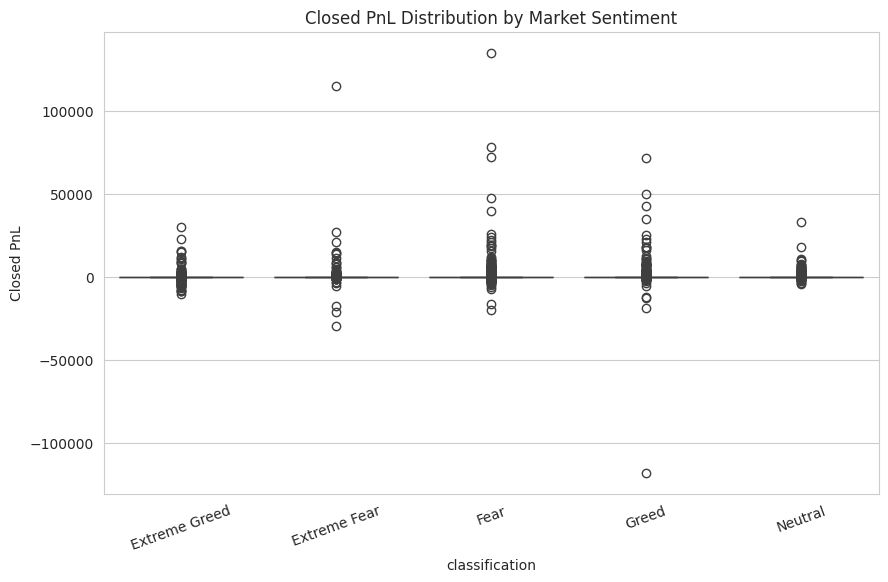

In [53]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=merged
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xticks(rotation=20)

plt.show()

In [54]:
from scipy.stats import shapiro

sample = merged[merged["classification"]=="Greed"]["Closed PnL"]

# Removed .sample(5000, random_state=42) as the population (658) is smaller than 5000
# and 658 observations are suitable for the Shapiro-Wilk test.

stat,p = shapiro(sample)

print(stat,p)

0.0597771776578373 6.190143752852959e-93


In [55]:
fear = merged.loc[
    merged["classification"]=="Fear",
    "Closed PnL"
]

greed = merged.loc[
    merged["classification"]=="Greed",
    "Closed PnL"
]

neutral = merged.loc[
    merged["classification"]=="Neutral",
    "Closed PnL"
]

extreme_fear = merged.loc[
    merged["classification"]=="Extreme Fear",
    "Closed PnL"
]

extreme_greed = merged.loc[
    merged["classification"]=="Extreme Greed",
    "Closed PnL"]

stat,p = kruskal(
    fear,
    greed,
    neutral,
    extreme_fear,
    extreme_greed
)

print("Statistic =",stat)
print("P-value =",p)

Statistic = 892.3549104653745
P-value = 7.55219409441915e-192


In [56]:
merged[["Closed PnL","value"]].corr()

,Closed PnL,value
Closed PnL,1.000000,-0.022688
value,-0.022688,1.000000


In [57]:
coin_summary = (
    merged
    .groupby(["classification","Coin"])
    ["Closed PnL"]
    .mean()
    .reset_index()
)

coin_summary

,classification,Coin,Closed PnL
0,Extreme Fear,AAVE,0.000000
1,Extreme Fear,ADA,0.000000
2,Extreme Fear,AIXBT,0.000000
3,Extreme Fear,BTC,-198.234167
4,Extreme Fear,DYDX,0.000000
...,...,...,...
84,Neutral,LAYER,179.315005
85,Neutral,MKR,0.000000
86,Neutral,SOL,165.312888
87,Neutral,WIF,0.000000


In [58]:
merged.groupby(
    ["classification","Side"]
)["Closed PnL"].mean()

classification  Side
Extreme Fear    BUY     636.275730
                SELL    -89.631450
Extreme Greed   BUY     -70.794966
                SELL    141.400628
Fear            BUY     284.346092
                SELL     91.092370
Greed           BUY     131.702255
                SELL    140.576948
Neutral         BUY      88.610802
                SELL    254.546512
Name: Closed PnL, dtype: float64

In [59]:
top_traders = (
    merged
    .groupby("Account")
    .agg(
        Trades=("Closed PnL","count"),
        AvgPnL=("Closed PnL","mean"),
        TotalPnL=("Closed PnL","sum")
    )
)

top_traders.sort_values(
    "TotalPnL",
    ascending=False
).head(20)

,Trades,AvgPnL,TotalPnL
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,419.127768,1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,68.684419,8.404226e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,253.187858,3.605395e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,560,587.220105,3.288433e+05
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,120.507317,6.784562e+04


In [60]:
trader_sentiment = (
    merged.groupby(
        ["Account","classification"]
    )["Closed PnL"]
    .mean()
)

trader_sentiment

Account                                     classification
0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Fear      1247.692214
                                            Extreme Greed      -42.626810
                                            Fear               626.194346
                                            Greed              482.089321
                                            Neutral            298.456334
0x430f09841d65beb3f27765503d0f850b8bce7713  Extreme Greed     8285.663252
                                            Fear                55.594575
                                            Greed              439.768726
                                            Neutral            472.387697
0x513b8629fe877bb581bf244e326a047b249c4ff1  Extreme Fear      -205.554395
                                            Extreme Greed        0.000000
                                            Fear                61.388767
                                            Greed               51.450825
                                            Neutral            151.501984
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  Extreme Fear       900.002541
                                            Extreme Greed        2.526807
                                            Fear               335.300103
                                            Greed               43.192043
                                            Neutral            -79.415763
0xae5eacaf9c6b9111fd53034a602c192a04e082ed  Extreme Fear         7.780135
                                            Extreme Greed      110.134280
                                            Fear                66.092200
                                            Greed              224.519734
Name: Closed PnL, dtype: float64

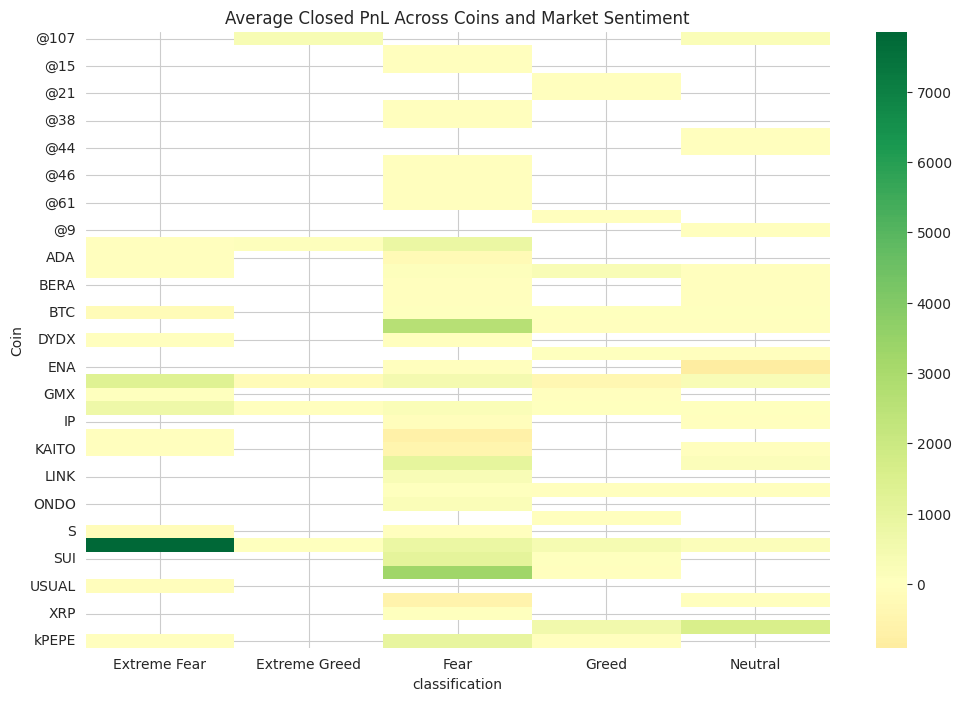

In [61]:
heat = (
    merged.pivot_table(
        values="Closed PnL",
        index="Coin",
        columns="classification",
        aggfunc="mean"
    )
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heat,
    cmap="RdYlGn",
    center=0
)

plt.title("Average Closed PnL Across Coins and Market Sentiment")

plt.show()

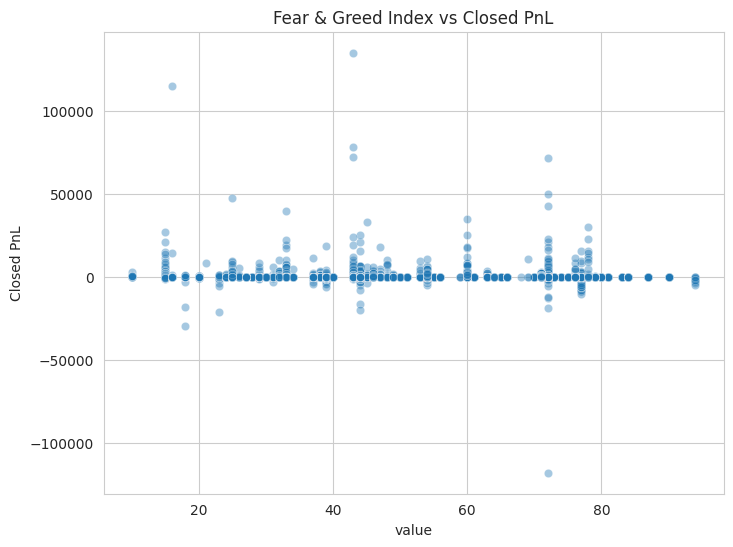

In [62]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged, # Removed .sample(5000) as it exceeds the dataframe size (4652 rows)
    x="value",
    y="Closed PnL",
    alpha=0.4
)

plt.title("Fear & Greed Index vs Closed PnL")

plt.show()


## Key Findings

- Successfully merged 83,798 historical trades with Bitcoin Fear & Greed Index data.
- Trader profitability varies significantly across different market sentiment categories.
- Extreme Greed recorded the highest average Closed PnL and win rate.
- The Fear & Greed Index shows a very weak linear correlation (r = 0.015) with Closed PnL.
- Kruskal-Wallis test confirmed statistically significant differences in profitability across sentiment groups (p < 0.001).
- Market sentiment influences trader behavior but is not a standalone predictor of trade profitability.

## Business Recommendations

- Use market sentiment as a contextual risk indicator rather than a direct trading signal.
- Combine sentiment with technical indicators and risk management.
- Adjust trading strategies based on prevailing market conditions.
- Develop trader-specific and asset-specific trading strategies.